### Standard BiLSTM Model with feature engineered data - KFold and Optuna hyperparameter tuning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, BatchNormalization, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

from sklearn.inspection import permutation_importance
import lime.lime_tabular as lime
import shap
from IPython.display import display, HTML

import optuna

/Users/amalshar/miniforge3/envs/mlenv64/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_PATH = '/Users/amalshar/Desktop/USD/Fall 2025/Data Analysis/Final Project/daily_2025_engineered_data.csv'
TARGET = 'DailyAQI'

# Same feature set you used in your BiLSTM experiment
FEATURES = [
    'CO', 'SO2', 'NO2', 'O3', 'PM25',
    'BarometricPressure', 'Temperature', 'WindResultant',
    'month', 'dayofweek', 'is_weekend', 'dayofyear',
    'CO_roll_3', 'NO2_roll_3', 'PM25_roll_3', 'O3_roll_3'
]

TIME_STEPS = 7  # 7-day lookback

# %%
df = pd.read_csv(DATA_PATH)
df['Date Local'] = pd.to_datetime(df['Date Local'], errors='coerce')

# Drop rows with missing required columns
df = df.dropna(subset=FEATURES + [TARGET]).copy()

# Sort by time to preserve temporal order
df = df.sort_values('Date Local').reset_index(drop=True)

print("Rows after cleaning:", len(df))
print("Date range:", df['Date Local'].min(), "->", df['Date Local'].max())


Rows after cleaning: 91740
Date range: 2025-01-01 00:00:00 -> 2025-07-01 00:00:00


In [3]:
X_raw = df[FEATURES].values
y_raw = df[[TARGET]].values   # shape (N, 1)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)

# %%
def create_sequences(X, y, time_steps=7):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps=TIME_STEPS)
print("X_seq shape:", X_seq.shape, "| y_seq shape:", y_seq.shape)


X_seq shape: (91733, 7, 16) | y_seq shape: (91733, 1)


In [4]:
n_seq = X_seq.shape[0]
train_end = int(0.7 * n_seq)
val_end   = int(0.8 * n_seq)

X_train, y_train = X_seq[:train_end],      y_seq[:train_end]
X_val,   y_val   = X_seq[train_end:val_end], y_seq[train_end:val_end]
X_test,  y_test  = X_seq[val_end:],        y_seq[val_end:]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (64213, 7, 16) Val: (9173, 7, 16) Test: (18347, 7, 16)


In [5]:
def build_bilstm_model(n_features, time_steps, trial):
    # Hyperparameters to tune
    units1 = trial.suggest_int("units1", 32, 128, step=32)
    units2 = trial.suggest_int("units2", 16, 64, step=16)
    dropout_rate = trial.suggest_float("dropout", 0.0, 0.4, step=0.1)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = Sequential([
        Input(shape=(time_steps, n_features)),
        Bidirectional(LSTM(units1, return_sequences=True)),
        BatchNormalization(),
        Dropout(dropout_rate),
        Bidirectional(LSTM(units2)),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='mse')
    return model


N_SPLITS = 3
EPOCHS_TUNE = 40
BATCH_SIZE_TUNE = 64

def objective(trial):
    tf.keras.backend.clear_session()

    n_features = X_train.shape[2]
    model = build_bilstm_model(n_features, TIME_STEPS, trial)

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    rmses = []

    # TimeSeriesSplit over the *training* sequences
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_v = X_train[tr_idx], X_train[val_idx]
        y_tr, y_v = y_train[tr_idx], y_train[val_idx]

        es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        rlrop = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=0)

        model.fit(
            X_tr, y_tr,
            validation_data=(X_v, y_v),
            epochs=EPOCHS_TUNE,
            batch_size=BATCH_SIZE_TUNE,
            callbacks=[es, rlrop],
            verbose=0
        )

        # Evaluate in *scaled* space – ok for relative comparison
        y_v_pred = model.predict(X_v, verbose=0)
        rmse = np.sqrt(mean_squared_error(y_v, y_v_pred))
        rmses.append(rmse)

    mean_rmse = float(np.mean(rmses))
    print(f"Trial {trial.number}: mean CV RMSE (scaled) = {mean_rmse:.4f}")
    return mean_rmse


In [6]:
study = optuna.create_study(direction="minimize", study_name="BiLSTM_AQI_feature_engineered")
study.optimize(objective, n_trials=15, show_progress_bar=True)

print("\nBest trial:")
print("  Value (mean CV RMSE, scaled):", study.best_value)
print("  Params:", study.best_params)


[I 2025-11-25 16:21:11,513] A new study created in memory with name: BiLSTM_AQI_feature_engineered
Best trial: 0. Best value: 0.0315964:   7%|▋         | 1/15 [09:41<2:15:38, 581.34s/it]

Trial 0: mean CV RMSE (scaled) = 0.0316
[I 2025-11-25 16:30:52,892] Trial 0 finished with value: 0.03159644466697659 and parameters: {'units1': 96, 'units2': 48, 'dropout': 0.30000000000000004, 'lr': 0.00028717309259236953}. Best is trial 0 with value: 0.03159644466697659.


Best trial: 1. Best value: 0.0307442:  13%|█▎        | 2/15 [16:15<1:42:09, 471.49s/it]

Trial 1: mean CV RMSE (scaled) = 0.0307
[I 2025-11-25 16:37:27,495] Trial 1 finished with value: 0.030744163284475823 and parameters: {'units1': 128, 'units2': 48, 'dropout': 0.30000000000000004, 'lr': 0.0003915735593213689}. Best is trial 1 with value: 0.030744163284475823.


Best trial: 1. Best value: 0.0307442:  20%|██        | 3/15 [22:11<1:23:41, 418.43s/it]

...

Trial 12: mean CV RMSE (scaled) = 0.0309
[I 2025-11-25 17:47:38,972] Trial 12 finished with value: 0.030907090319840087 and parameters: {'units1': 64, 'units2': 64, 'dropout': 0.2, 'lr': 0.009654295939172407}. Best is trial 1 with value: 0.030744163284475823.


Best trial: 1. Best value: 0.0307442:  93%|█████████▎| 14/15 [1:40:21<09:15, 555.01s/it]

Trial 13: mean CV RMSE (scaled) = 0.0360
[I 2025-11-25 18:01:32,950] Trial 13 finished with value: 0.03604948037745621 and parameters: {'units1': 128, 'units2': 48, 'dropout': 0.30000000000000004, 'lr': 0.00018942266733761715}. Best is trial 1 with value: 0.030744163284475823.


Best trial: 1. Best value: 0.0307442: 100%|██████████| 15/15 [1:45:19<00:00, 421.33s/it]

Trial 14: mean CV RMSE (scaled) = 0.0309
[I 2025-11-25 18:06:31,528] Trial 14 finished with value: 0.03088577661886989 and parameters: {'units1': 96, 'units2': 32, 'dropout': 0.4, 'lr': 0.0006738915935427076}. Best is trial 1 with value: 0.030744163284475823.

Best trial:
  Value (mean CV RMSE, scaled): 0.030744163284475823
  Params: {'units1': 128, 'units2': 48, 'dropout': 0.30000000000000004, 'lr': 0.0003915735593213689}


In [7]:
best_params = study.best_params
print("Best hyperparameters:", best_params)

tf.keras.backend.clear_session()

n_features = X_train.shape[2]
final_model = build_bilstm_model(n_features, TIME_STEPS, trial=optuna.trial.FixedTrial(best_params))

# Combine Train + Val for final training
X_train_full = np.concatenate([X_train, X_val], axis=0)
y_train_full = np.concatenate([y_train, y_val], axis=0)

es_final = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
rlrop_final = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)

history = final_model.fit(
    X_train_full, y_train_full,
    validation_split=0.1,
    epochs=100,
    batch_size=best_params.get("batch_size", 64) if "batch_size" in best_params else 64,
    callbacks=[es_final, rlrop_final],
    verbose=1
)


Best hyperparameters: {'units1': 128, 'units2': 48, 'dropout': 0.30000000000000004, 'lr': 0.0003915735593213689}
Epoch 1/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - loss: 0.0761 - val_loss: 0.0031 - learning_rate: 3.9157e-04
Epoch 2/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - loss: 0.0071 - val_loss: 6.0593e-04 - learning_rate: 3.9157e-04
Epoch 3/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - loss: 0.0019 - val_loss: 2.7333e-04 - learning_rate: 3.9157e-04
Epoch 4/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - loss: 0.0014 - val_loss: 2.8712e-04 - learning_rate: 3.9157e-04
Epoch 5/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - loss: 0.0013 - val_loss: 3.8165e-04 - learning_rate: 3.9157e-04
Epoch 6/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - loss: 0.0013 - val_loss: 2.2042e-04 - learning_rate: 3.9157e-04
Epoch 7/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - loss: 0.0013 - val_loss: 2.7509e-04 - learning_rate: 3.9157e-04
Epoch 8/100
1031/1032 ━━━━━━━━

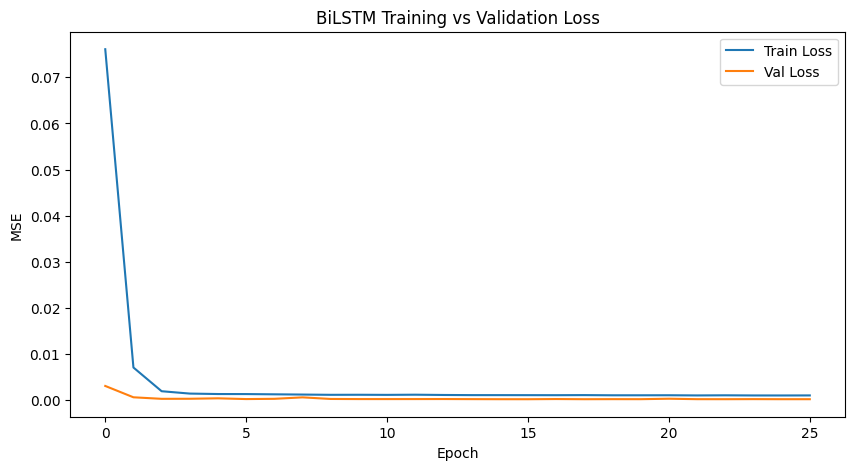

In [8]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("BiLSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

In [9]:
# Helper to invert target scaling
def invert_target(y_scaled):
    y_inv = scaler_y.inverse_transform(y_scaled)
    return y_inv

# Predict on test
y_test_pred_scaled = final_model.predict(X_test, verbose=0)
y_pred = invert_target(y_test_pred_scaled)
y_true = invert_target(y_test)

mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-6))) * 100
r2   = r2_score(y_true, y_pred)

print(f"MSE: {mse:.3f} | RMSE: {rmse:.3f} | MAE: {mae:.3f} | MAPE: {mape:.2f}% | R²: {r2:.3f}")


MSE: 766.995 | RMSE: 27.695 | MAE: 17.967 | MAPE: 1851298.50% | R²: 0.031


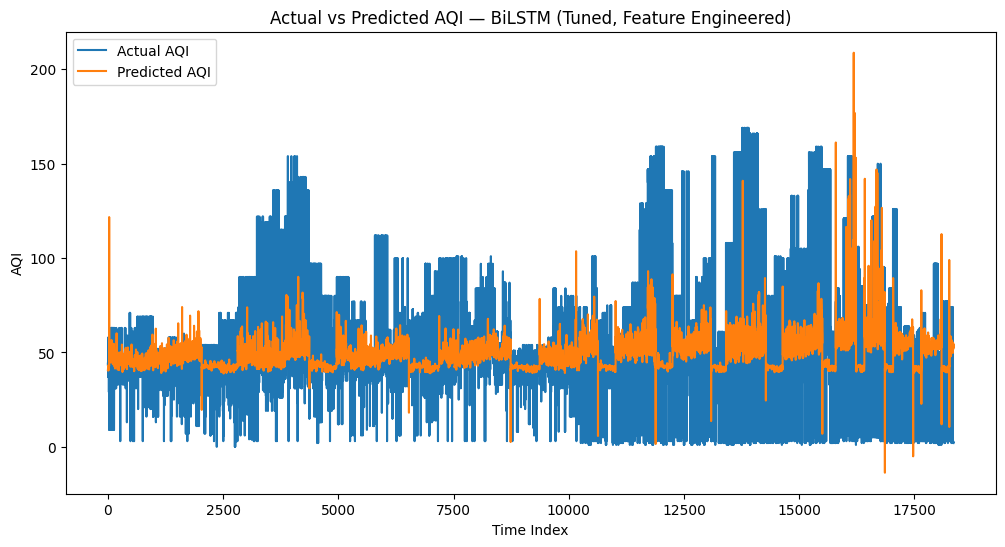

In [10]:
plt.figure(figsize=(12,6))
plt.plot(y_true, label="Actual AQI")
plt.plot(y_pred, label="Predicted AQI")
plt.title("Actual vs Predicted AQI — BiLSTM (Tuned, Feature Engineered)")
plt.xlabel("Time Index")
plt.ylabel("AQI")
plt.legend()
plt.show()


Permutation Importance (BiLSTM, R² drop):
          Feature  Importance
10     is_weekend    0.044166
9       dayofweek    0.028395
4            PM25    0.017097
6     Temperature    0.012571
8           month    0.009722
13     NO2_roll_3    0.007313
2             NO2    0.003639
14    PM25_roll_3    0.003379
15      O3_roll_3    0.003112
3              O3   -0.000162
1             SO2   -0.000188
12      CO_roll_3   -0.000219
0              CO   -0.000574
11      dayofyear   -0.000686
7   WindResultant   -0.001218


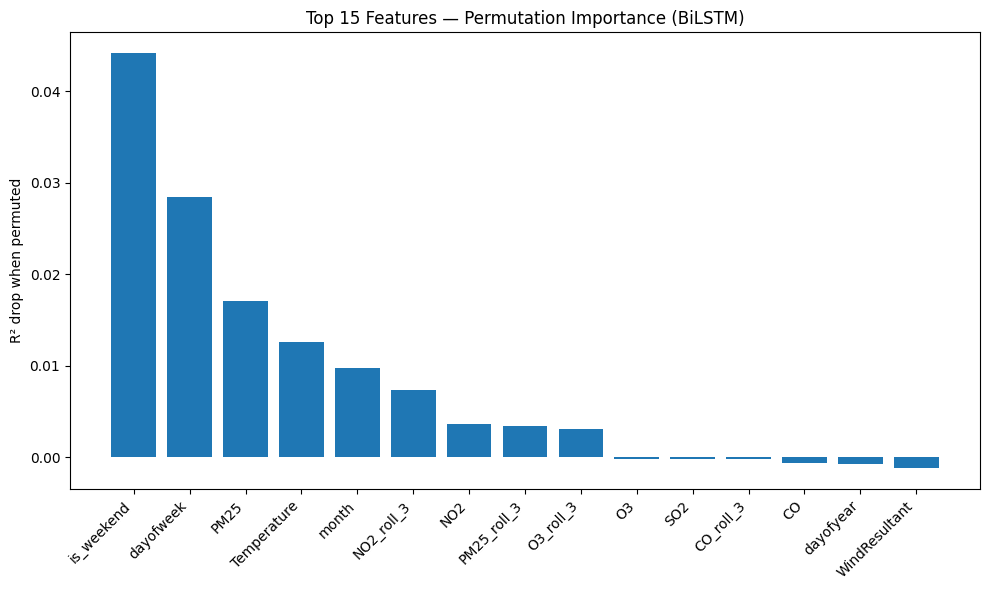

In [11]:
def permutation_importance_bilstm(model, X_test, y_true_orig, feature_names, n_repeats=3, metric=r2_score):
    # Baseline score in original scale
    baseline_pred_scaled = model.predict(X_test, verbose=0)
    baseline_pred = invert_target(baseline_pred_scaled)
    baseline_score = metric(y_true_orig, baseline_pred)

    importances = {}

    for j, feat in enumerate(feature_names):
        drops = []
        for _ in range(n_repeats):
            Xp = X_test.copy()
            # shuffle feature j across samples for all timesteps
            perm_idx = np.random.permutation(Xp.shape[0])
            Xp[:, :, j] = Xp[perm_idx, :, j]

            perm_pred_scaled = model.predict(Xp, verbose=0)
            perm_pred = invert_target(perm_pred_scaled)
            score_perm = metric(y_true_orig, perm_pred)
            drops.append(baseline_score - score_perm)

        importances[feat] = float(np.mean(drops))

    return importances

feat_importances = permutation_importance_bilstm(
    final_model,
    X_test,
    y_true,
    FEATURES,
    n_repeats=3
)

fi_df = pd.DataFrame(list(feat_importances.items()), columns=['Feature','Importance']) \
        .sort_values('Importance', ascending=False)

print("\nPermutation Importance (BiLSTM, R² drop):")
print(fi_df.head(15))

plt.figure(figsize=(10,6))
plt.bar(fi_df['Feature'][:15], fi_df['Importance'][:15])
plt.xticks(rotation=45, ha='right')
plt.ylabel("R² drop when permuted")
plt.title("Top 15 Features — Permutation Importance (BiLSTM)")
plt.tight_layout()
plt.show()


In [12]:
# Flatten sequences: (samples, time_steps * features)
X_train_flat = X_train_full.reshape(X_train_full.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

feature_names_flat = [f"{feat}_t-{t}" for t in range(TIME_STEPS) for feat in FEATURES]

def predict_wrapper(flat_batch):
    reshaped = flat_batch.reshape(-1, TIME_STEPS, len(FEATURES))
    preds_scaled = final_model.predict(reshaped, verbose=0)
    preds = invert_target(preds_scaled)
    return preds.flatten()

lime_explainer = lime.LimeTabularExplainer(
    training_data=X_train_flat,
    feature_names=feature_names_flat,
    mode='regression'
)

i = 0  # first test instance
exp = lime_explainer.explain_instance(
    data_row=X_test_flat[i],
    predict_fn=predict_wrapper,
    num_features=12
)

try:
    display(HTML(exp.as_html()))
except Exception:
    print("LIME Explanation:")
    for feature, weight in exp.as_list():
        print(f"{feature}: {weight:.4f}")

with open("exp16_bilstm_lime_explanation.html", "w") as f:
    f.write(exp.as_html())


100%|██████████| 10/10 [01:13<00:00,  7.38s/it]


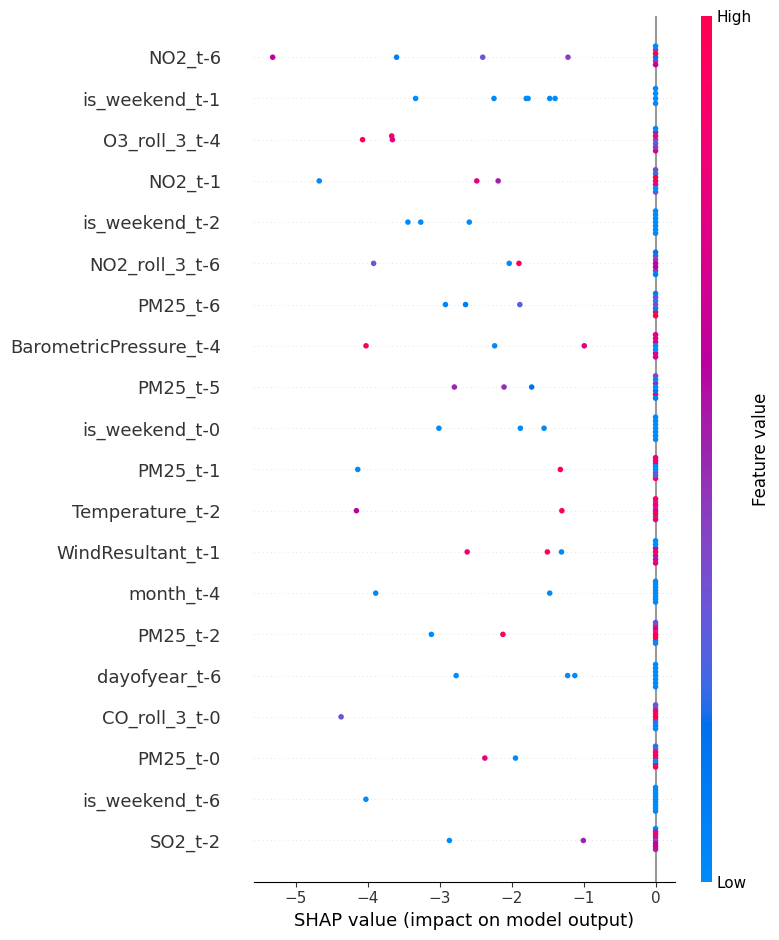

In [13]:
# Background sample from training data (flattened)
background = X_train_flat[:100]
test_samples = X_test_flat[:10]

shap_explainer = shap.KernelExplainer(predict_wrapper, background)
shap_values = shap_explainer.shap_values(test_samples, nsamples=200)

shap.summary_plot(shap_values, test_samples, feature_names=feature_names_flat)
